In [1]:
import pandas as pd
import numpy as np
sales = pd.read_csv('/content/business.retail sales.csv')
sales.head()


,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Art & Sculpture,34,14935.0,-594.00,-1609.0,12732.00
1,Basket,13,3744.0,-316.80,0.0,3427.20
2,Basket,12,3825.0,-201.60,-288.0,3335.40
3,Basket,17,3035.0,-63.25,0.0,2971.75
4,Art & Sculpture,47,2696.8,-44.16,0.0,2652.64


In [2]:
sales.columns.tolist()

['Product Type',
 'Net Quantity',
 'Gross Sales',
 'Discounts',
 'Returns',
 'Total Net Sales']

In [5]:
len(sales)

1775

In [7]:
sales.duplicated().sum()

np.int64(512)

In [9]:
sales = sales.drop_duplicates()

In [10]:
sales.duplicated().sum()

np.int64(0)

In [11]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1263 entries, 0 to 1774
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Type     1256 non-null   object 
 1   Net Quantity     1263 non-null   int64  
 2   Gross Sales      1263 non-null   float64
 3   Discounts        1263 non-null   float64
 4   Returns          1263 non-null   float64
 5   Total Net Sales  1263 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 69.1+ KB


In [15]:
sales[['Discounts', 'Returns']] = sales[['Discounts', 'Returns']].abs()

In [16]:
print(sales['Discounts'])

0       594.00
1       316.80
2       201.60
3        63.25
4        44.16
         ...  
1770      2.81
1771      0.00
1772     23.20
1773      0.00
1774      0.00
Name: Discounts, Length: 1263, dtype: float64


In [18]:
sales.isnull().sum()

,0
Product Type,7
Net Quantity,0
Gross Sales,0
Discounts,0
Returns,0
Total Net Sales,0


In [19]:
sales['Product Type'] = sales['Product Type'].fillna('Unknown')

In [21]:
sales['Product Type'].isnull().sum()

np.int64(0)

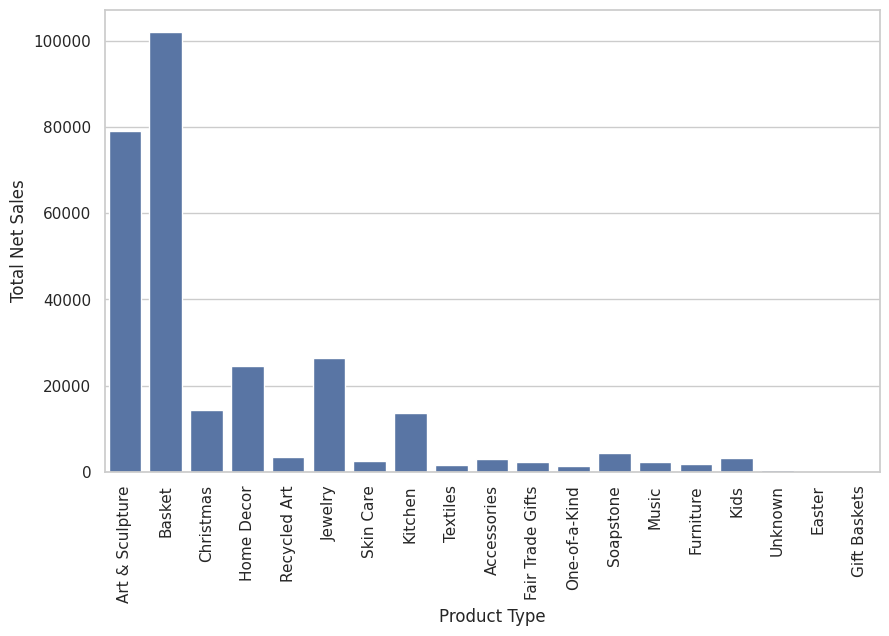

In [34]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.barplot(data=sales, x='Product Type', y='Total Net Sales', estimator= 'sum', errorbar=None)
plt.xticks(rotation=90)
plt.show()

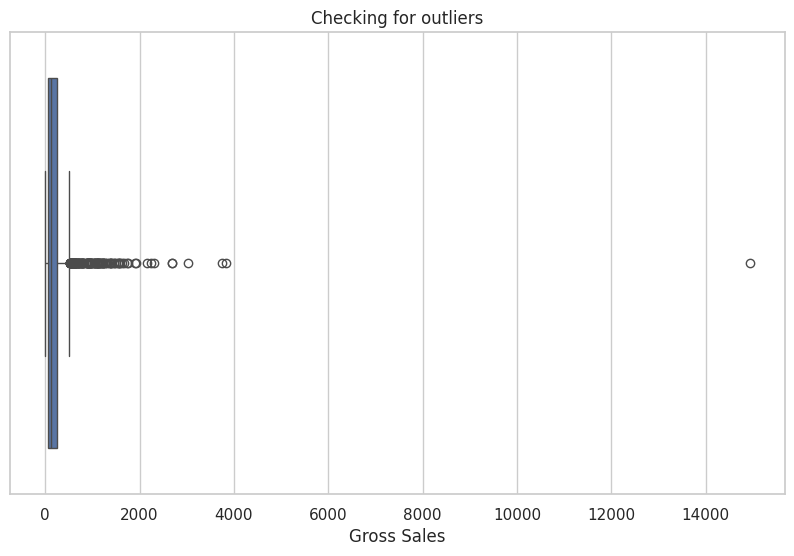

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=sales['Gross Sales'])
plt.title('Checking for outliers')
plt.show()

In [31]:
print(sales[sales['Gross Sales'] > 10000])

      Product Type  Net Quantity  Gross Sales  Discounts  Returns  \
0  Art & Sculpture            34      14935.0      594.0   1609.0   

   Total Net Sales  
0          12732.0  


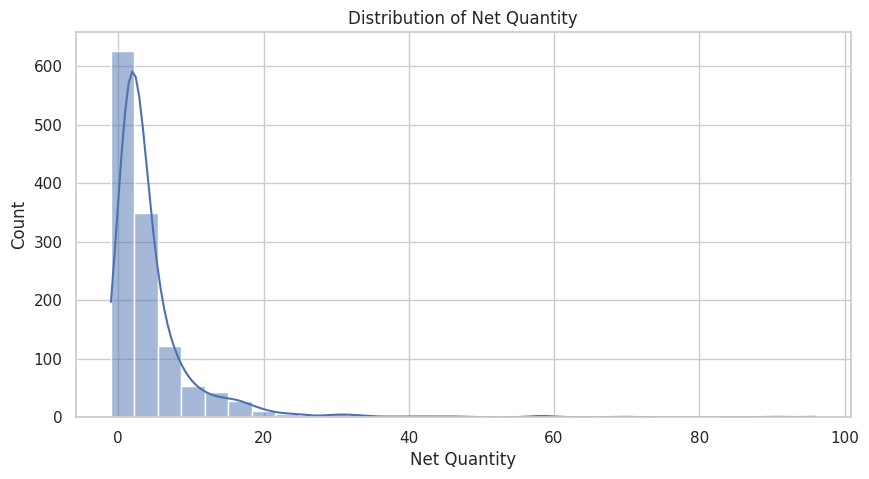

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(sales['Net Quantity'], kde=True, bins=30)
plt.title('Distribution of Net Quantity')
plt.show()

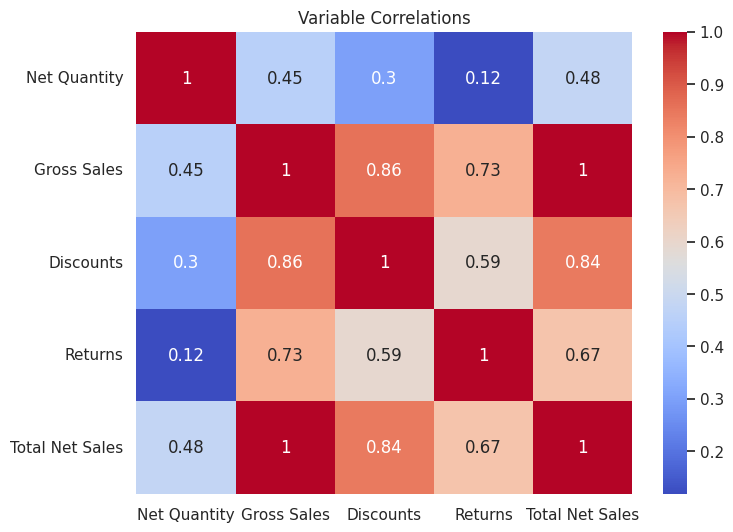

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(sales.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Variable Correlations')
plt.show()